In [ ]:
# Colab already ships numpy, scipy, scikit-learn, tensorflow, pandas, etc.
# We only ADD the audio libraries and do NOT downgrade the preinstalled stack
# (that downgrade is what broke the TensorFlow/JAX import last time).
!pip install -q librosa soundfile soxr audioread

import librosa, tensorflow as tf, numpy as np, sklearn, scipy
print("librosa", librosa.__version__, "| tensorflow", tf.__version__,
      "| numpy", np.__version__, "| sklearn", sklearn.__version__,
      "| scipy", scipy.__version__)

librosa 0.11.0 | tensorflow 2.20.0 | numpy 2.0.2 | sklearn 1.6.1 | scipy 1.16.3


In [ ]:
%%writefile features.py
"""Single source of truth for audio loading + feature extraction.
IDENTICAL copy lives in the repo as features.py and is imported by
train_pipeline.py, predict.py and app.py. Do not change params in one place only.
"""
from __future__ import annotations
import warnings
import numpy as np
import librosa

SR: int = 16_000
DURATION: float = 4.0
N_SAMPLES: int = int(SR * DURATION)   # 64_000
N_MFCC: int = 40
# MFCC 80 + chroma 24 + contrast 14 + zcr 2 + rms 2 + rolloff 2 = 124
N_FEATURES: int = 124


def load_audio(path: str, sr: int = SR, duration: float = DURATION) -> np.ndarray:
    y, _ = librosa.load(path, sr=sr, mono=True)
    target = int(sr * duration)
    if len(y) < target:
        y = np.pad(y, (0, target - len(y)), mode="constant")
    else:
        y = y[:target]
    return y


def extract_features(y: np.ndarray, sr: int = SR) -> np.ndarray:
    """Fixed (124,) float32 vector. Order is fixed; do not reorder."""
    y = np.asarray(y, dtype=np.float32)
    if not np.any(y):                       # guard fully-silent clips
        y = y + 1e-10
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        mfcc     = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
        chroma   = librosa.feature.chroma_stft(y=y, sr=sr)
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        zcr      = librosa.feature.zero_crossing_rate(y=y)
        rms      = librosa.feature.rms(y=y)
        rolloff  = librosa.feature.spectral_rolloff(y=y, sr=sr)
    feats = np.concatenate([
        np.mean(mfcc,     axis=1), np.std(mfcc,     axis=1),
        np.mean(chroma,   axis=1), np.std(chroma,   axis=1),
        np.mean(contrast, axis=1), np.std(contrast, axis=1),
        [np.mean(zcr)],     [np.std(zcr)],
        [np.mean(rms)],     [np.std(rms)],
        [np.mean(rolloff)], [np.std(rolloff)],
    ]).astype(np.float32)
    return np.nan_to_num(feats, nan=0.0, posinf=0.0, neginf=0.0)


def extract_features_from_file(path: str, sr: int = SR,
                               duration: float = DURATION) -> np.ndarray:
    return extract_features(load_audio(path, sr=sr, duration=duration), sr=sr)

Writing features.py


In [ ]:
import os, glob, random, numpy as np, joblib
from tqdm.auto import tqdm
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, f1_score, roc_curve,
                             confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

from features import extract_features_from_file, N_FEATURES, SR, DURATION

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
CLASSES = [("real", 0), ("fake", 1)]      # real=Genuine=0, fake=Deepfake=1

# ⚠️ Keep this architecture IDENTICAL to build_model in train_pipeline.py
def build_model(input_dim):
    model = keras.Sequential([
        keras.layers.Input(shape=(input_dim,)),
        keras.layers.Dense(256, name="dense_1"),
        keras.layers.BatchNormalization(name="bn_1"),
        keras.layers.Activation("relu", name="act_1"),
        keras.layers.Dropout(0.4, name="drop_1"),
        keras.layers.Dense(128, name="dense_2"),
        keras.layers.BatchNormalization(name="bn_2"),
        keras.layers.Activation("relu", name="act_2"),
        keras.layers.Dropout(0.3, name="drop_2"),
        keras.layers.Dense(64, name="dense_3"),
        keras.layers.BatchNormalization(name="bn_3"),
        keras.layers.Activation("relu", name="act_3"),
        keras.layers.Dropout(0.2, name="drop_3"),
        keras.layers.Dense(1, activation="sigmoid", name="out"),
    ], name="deepfake_mlp")
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy", metrics=["accuracy"])
    return model

print("TF", tf.__version__, "| feature dim", N_FEATURES)

TF 2.20.0 | feature dim 124


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

# Where artifacts (model, scaler, caches, plots) are saved on Drive:
DRIVE_DIR = "/content/drive/MyDrive/deepfake_audio"
os.makedirs(DRIVE_DIR, exist_ok=True)
CACHE_DIR = os.path.join(DRIVE_DIR, "feature_cache"); os.makedirs(CACHE_DIR, exist_ok=True)

# Local copy you download + commit to GitHub:
REPO_ART = "/content/repo_artifacts"; os.makedirs(REPO_ART, exist_ok=True)

MAX_PER_CLASS = 4000      # lower to 2000 for a faster first run
EPOCHS, BATCH = 120, 64
print("Drive dir:", DRIVE_DIR)

Mounted at /content/drive
Drive dir: /content/drive/MyDrive/deepfake_audio


In [ ]:
# EDIT this path to your zip on Drive, then run. Skip if already extracted.
ZIP_PATH = "/content/drive/MyDrive/archive (1).zip"  # <-- edit me

import zipfile
if os.path.exists(ZIP_PATH):
    print("Unzipping (one-time)…")
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall("/content/for_dataset")
    print("Done -> /content/for_dataset")
else:
    print(f"No zip at {ZIP_PATH}. If your data is already extracted, that's fine — "
          "just make sure Cell 7's search roots include its location.")

Unzipping (one-time)…
Done -> /content/for_dataset


In [ ]:
SEARCH_ROOTS = ["/content/for_dataset", "/content", DRIVE_DIR, "/content/drive/MyDrive"]

def _has_real_fake(d):
    return os.path.isdir(os.path.join(d, "real")) and os.path.isdir(os.path.join(d, "fake"))

def find_dataset_root(roots):
    norm_match = any_match = None
    for root in roots:
        if not os.path.isdir(root):
            continue
        for dp, _, _ in os.walk(root):
            train = os.path.join(dp, "training")
            if os.path.isdir(train) and _has_real_fake(train):
                if "norm" in os.path.basename(dp).lower() and norm_match is None:
                    norm_match = dp
                if any_match is None:
                    any_match = dp
        if norm_match:
            break
    chosen = norm_match or any_match
    if not chosen:
        raise FileNotFoundError("No folder with training/{real,fake} found. "
                                "Check ZIP_PATH / SEARCH_ROOTS.")
    return chosen

def pick_eval_split(root):
    for name in ("testing", "validation"):
        c = os.path.join(root, name)
        if os.path.isdir(c) and _has_real_fake(c):
            return c
    raise FileNotFoundError("No testing/ or validation/ split with real/fake.")

DATA_ROOT = find_dataset_root(SEARCH_ROOTS)
TRAIN_DIR = os.path.join(DATA_ROOT, "training")
EVAL_DIR  = pick_eval_split(DATA_ROOT)
print("Dataset root :", DATA_ROOT)
print("Train split  :", TRAIN_DIR)
print("Eval split   :", EVAL_DIR)

Dataset root : /content/for_dataset/for-norm/for-norm
Train split  : /content/for_dataset/for-norm/for-norm/training
Eval split   : /content/for_dataset/for-norm/for-norm/testing


In [ ]:
AUDIO_EXTS = ("*.wav", "*.WAV", "*.flac", "*.mp3")

def _list_files(class_dir):
    files = []
    for pat in AUDIO_EXTS:
        files += glob.glob(os.path.join(class_dir, pat))
    return sorted(files)

def build_split(split_dir, max_per_class, cache_path):
    if os.path.exists(cache_path):
        d = np.load(cache_path); print("  cache:", cache_path, d["X"].shape); return d["X"], d["y"]
    X, y = [], []
    for cls, label in CLASSES:
        files = _list_files(os.path.join(split_dir, cls))[:max_per_class]
        for f in tqdm(files, desc=f"{os.path.basename(split_dir)}/{cls}"):
            try:
                X.append(extract_features_from_file(f)); y.append(label)
            except Exception as e:
                print("  skip", f, e)
    X = np.asarray(X, np.float32); y = np.asarray(y, np.int64)
    assert X.shape[1] == N_FEATURES, X.shape
    np.savez_compressed(cache_path, X=X, y=y); print("  cached:", cache_path, X.shape)
    return X, y

print("TRAIN features…")
X_train_full, y_train_full = build_split(TRAIN_DIR, MAX_PER_CLASS,
                                         os.path.join(CACHE_DIR, f"train_{MAX_PER_CLASS}.npz"))
print("EVAL features…")
X_eval, y_eval = build_split(EVAL_DIR, MAX_PER_CLASS,
                             os.path.join(CACHE_DIR, f"eval_{MAX_PER_CLASS}.npz"))
print("Shapes:", X_train_full.shape, X_eval.shape,
      "| train balance:", np.bincount(y_train_full), "| eval balance:", np.bincount(y_eval))

TRAIN features…


training/real:   0%|          | 0/4000 [00:00<?, ?it/s]

training/fake:   0%|          | 0/4000 [00:00<?, ?it/s]

  cached: /content/drive/MyDrive/deepfake_audio/feature_cache/train_4000.npz (8000, 124)
EVAL features…


testing/real:   0%|          | 0/2264 [00:00<?, ?it/s]

testing/fake:   0%|          | 0/2370 [00:00<?, ?it/s]

  cached: /content/drive/MyDrive/deepfake_audio/feature_cache/eval_4000.npz (4634, 124)
Shapes: (8000, 124) (4634, 124) | train balance: [4000 4000] | eval balance: [2264 2370]


In [ ]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, stratify=y_train_full, random_state=SEED)

scaler = StandardScaler().fit(X_tr)
X_tr_s, X_val_s = scaler.transform(X_tr), scaler.transform(X_val)

joblib.dump(scaler, os.path.join(DRIVE_DIR, "scaler.pkl"))
joblib.dump(scaler, os.path.join(REPO_ART, "scaler.pkl"))
print("scaler saved. train:", X_tr_s.shape, "val:", X_val_s.shape)

scaler saved. train: (6800, 124) val: (1200, 124)


In [ ]:
classes = np.unique(y_tr)
cw = compute_class_weight("balanced", classes=classes, y=y_tr)
class_weight = {int(c): float(w) for c, w in zip(classes, cw)}
print("class weights:", class_weight)

model = build_model(X_tr_s.shape[1])
model.summary()

class weights: {0: 1.0, 1: 1.0}


Model: "deepfake_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 256)            │        32,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_1 (Activation)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_2 (Activation)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_3 (Activation)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out (Dense)                     │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,009 (293.00 KB)

 Trainable params: 74,113 (289.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5,
                                      min_lr=1e-6, verbose=1),
]
history = model.fit(X_tr_s, y_tr, validation_data=(X_val_s, y_val),
                    epochs=EPOCHS, batch_size=BATCH,
                    class_weight=class_weight, callbacks=callbacks, verbose=2)

Epoch 1/120
107/107 - 13s - 118ms/step - accuracy: 0.9028 - loss: 0.2376 - val_accuracy: 0.9725 - val_loss: 0.0917 - learning_rate: 0.0010
Epoch 2/120
107/107 - 1s - 10ms/step - accuracy: 0.9712 - loss: 0.0934 - val_accuracy: 0.9833 - val_loss: 0.0515 - learning_rate: 0.0010
Epoch 3/120
107/107 - 1s - 11ms/step - accuracy: 0.9799 - loss: 0.0605 - val_accuracy: 0.9875 - val_loss: 0.0412 - learning_rate: 0.0010
Epoch 4/120
107/107 - 1s - 7ms/step - accuracy: 0.9843 - loss: 0.0468 - val_accuracy: 0.9925 - val_loss: 0.0306 - learning_rate: 0.0010
Epoch 5/120
107/107 - 1s - 14ms/step - accuracy: 0.9879 - loss: 0.0352 - val_accuracy: 0.9950 - val_loss: 0.0200 - learning_rate: 0.0010
Epoch 6/120
107/107 - 1s - 7ms/step - accuracy: 0.9878 - loss: 0.0312 - val_accuracy: 0.9925 - val_loss: 0.0281 - learning_rate: 0.0010
Epoch 7/120
107/107 - 1s - 6ms/step - accuracy: 0.9891 - loss: 0.0293 - val_accuracy: 0.9950 - val_loss: 0.0212 - learning_rate: 0.0010
Epoch 8/120
107/107 - 1s - 6ms/step - accu

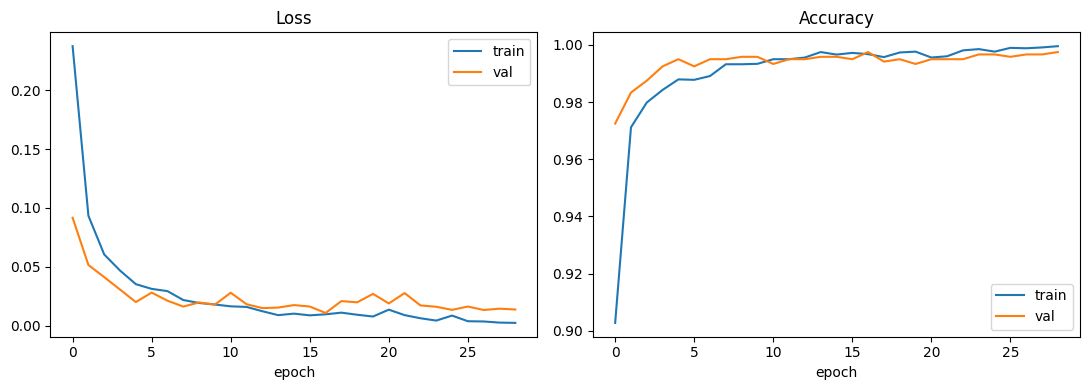

In [ ]:
h = history.history
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(h["loss"], label="train"); ax[0].plot(h["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(h["accuracy"], label="train"); ax[1].plot(h["val_accuracy"], label="val")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(REPO_ART, "training_history.png"), dpi=150)
plt.savefig(os.path.join(DRIVE_DIR, "training_history.png"), dpi=150)
plt.show()

                 precision    recall  f1-score   support

 real (Genuine)     0.6501    0.9766    0.7806      2264
fake (Deepfake)     0.9570    0.4979    0.6550      2370

       accuracy                         0.7318      4634
      macro avg     0.8036    0.7372    0.7178      4634
   weighted avg     0.8071    0.7318    0.7164      4634

Accuracy           : 73.18%
F1 score           : 65.50%
EER                : 11.22%  (thr=0.006)
Per-class accuracy : real=97.66%  fake=49.79%

--- PASS / FAIL ---
  [FAIL]  Accuracy >= 80%
  [PASS]  EER <= 12%
  [FAIL]  F1 >= 80%
  [PASS]  real acc >= 75%
  [FAIL]  fake acc >= 75%

OVERALL: SOME FAILED ❌


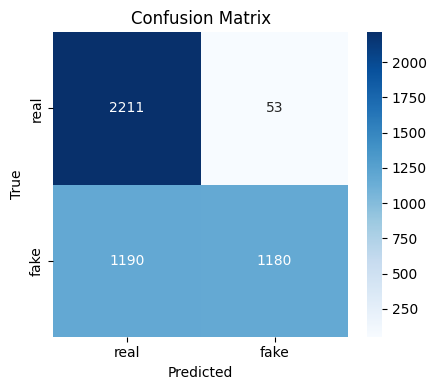

In [ ]:
def compute_eer(y_true, y_score):
    fpr, tpr, thr = roc_curve(y_true, y_score)
    fnr = 1.0 - tpr
    i = int(np.nanargmin(np.abs(fpr - fnr)))
    return float((fpr[i] + fnr[i]) / 2.0), float(thr[i])

proba  = model.predict(scaler.transform(X_eval), verbose=0).ravel()
y_pred = (proba >= 0.5).astype(int)

acc = accuracy_score(y_eval, y_pred)
f1  = f1_score(y_eval, y_pred)
eer, eer_thr = compute_eer(y_eval, proba)
cm  = confusion_matrix(y_eval, y_pred)
real_acc, fake_acc = (cm.diagonal() / cm.sum(axis=1))

print(classification_report(y_eval, y_pred,
      target_names=["real (Genuine)", "fake (Deepfake)"], digits=4))
print(f"Accuracy           : {acc*100:.2f}%")
print(f"F1 score           : {f1*100:.2f}%")
print(f"EER                : {eer*100:.2f}%  (thr={eer_thr:.3f})")
print(f"Per-class accuracy : real={real_acc*100:.2f}%  fake={fake_acc*100:.2f}%")

checks = {
    "Accuracy >= 80%": acc >= 0.80, "EER <= 12%": eer <= 0.12, "F1 >= 80%": f1 >= 0.80,
    "real acc >= 75%": real_acc >= 0.75, "fake acc >= 75%": fake_acc >= 0.75,
}
print("\n--- PASS / FAIL ---")
for k, v in checks.items():
    print(f"  [{'PASS' if v else 'FAIL'}]  {k}")
print(f"\nOVERALL: {'ALL PASSED ✅' if all(checks.values()) else 'SOME FAILED ❌'}")

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["real", "fake"], yticklabels=["real", "fake"])
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(REPO_ART, "confusion_matrix.png"), dpi=150)
plt.savefig(os.path.join(DRIVE_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

In [ ]:
from sklearn.metrics import balanced_accuracy_score

VAL_DIR = os.path.join(DATA_ROOT, "validation")
assert os.path.isdir(os.path.join(VAL_DIR, "real")) and os.path.isdir(os.path.join(VAL_DIR, "fake")), \
    f"No validation/real|fake under {VAL_DIR}"

print("Extracting VALIDATION features (for cutoff tuning)…")
X_valoff, y_valoff = build_split(
    VAL_DIR, MAX_PER_CLASS, os.path.join(CACHE_DIR, f"valoff_{MAX_PER_CLASS}.npz"))

p_val = model.predict(scaler.transform(X_valoff), verbose=0).ravel()

# Best cutoff = the one that balances accuracy across BOTH classes on VALIDATION
# (tuned on validation, never on the test set, so it generalizes to private data).
grid = np.linspace(0.001, 0.999, 999)
bal  = np.array([balanced_accuracy_score(y_valoff, (p_val >= t).astype(int)) for t in grid])
BEST_T = float(grid[int(bal.argmax())])
print(f"Tuned cutoff = {BEST_T:.4f}  (validation balanced accuracy = {bal.max():.4f})")

Extracting VALIDATION features (for cutoff tuning)…


validation/real:   0%|          | 0/4000 [00:00<?, ?it/s]

validation/fake:   0%|          | 0/4000 [00:00<?, ?it/s]

  cached: /content/drive/MyDrive/deepfake_audio/feature_cache/valoff_4000.npz (8000, 124)
Tuned cutoff = 0.6570  (validation balanced accuracy = 0.9964)


In [ ]:
import json

proba  = model.predict(scaler.transform(X_eval), verbose=0).ravel()
y_pred = (proba >= BEST_T).astype(int)

acc = accuracy_score(y_eval, y_pred); f1 = f1_score(y_eval, y_pred)
eer, _ = compute_eer(y_eval, proba)
cm = confusion_matrix(y_eval, y_pred)
real_acc, fake_acc = (cm.diagonal() / cm.sum(axis=1))

print(f"Cutoff used        : {BEST_T:.4f}")
print(f"Accuracy           : {acc*100:.2f}%")
print(f"F1 score           : {f1*100:.2f}%")
print(f"EER                : {eer*100:.2f}%")
print(f"Per-class accuracy : real={real_acc*100:.2f}%  fake={fake_acc*100:.2f}%")
print(f"Confusion matrix   :\n{cm}")

checks = {"Accuracy >= 80%": acc>=.80, "EER <= 12%": eer<=.12, "F1 >= 80%": f1>=.80,
          "real acc >= 75%": real_acc>=.75, "fake acc >= 75%": fake_acc>=.75}
print("\n--- PASS / FAIL ---")
for k, v in checks.items(): print(f"  [{'PASS' if v else 'FAIL'}]  {k}")
print(f"\nOVERALL: {'ALL PASSED' if all(checks.values()) else 'SOME FAILED'}")

# Save the cutoff next to the model so the app/CLI use the SAME value.
for d in (DRIVE_DIR, REPO_ART):
    with open(os.path.join(d, "threshold.json"), "w") as f:
        json.dump({"threshold": BEST_T}, f)
print("\nSaved threshold.json to Drive and repo_artifacts.")

Cutoff used        : 0.6570
Accuracy           : 70.89%
F1 score           : 61.27%
EER                : 11.22%
Per-class accuracy : real=97.97%  fake=45.02%
Confusion matrix   :
[[2218   46]
 [1303 1067]]

--- PASS / FAIL ---
  [FAIL]  Accuracy >= 80%
  [PASS]  EER <= 12%
  [FAIL]  F1 >= 80%
  [PASS]  real acc >= 75%
  [FAIL]  fake acc >= 75%

OVERALL: SOME FAILED

Saved threshold.json to Drive and repo_artifacts.


In [ ]:
# Try several "fake importance" weights; report TEST scores for each. Pick the balanced one.
for w in [2.0, 3.0, 4.0, 5.0, 6.0]:
    m = build_model(X_tr_s.shape[1])
    m.fit(X_tr_s, y_tr, validation_data=(X_val_s, y_val),
          epochs=60, batch_size=64, class_weight={0: 1.0, 1: w},
          callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=8,
                                                   restore_best_weights=True)],
          verbose=0)
    pr = m.predict(scaler.transform(X_eval), verbose=0).ravel()
    yp = (pr >= 0.5).astype(int)
    cmx = confusion_matrix(y_eval, yp); ra, fa = cmx.diagonal() / cmx.sum(axis=1)
    a = accuracy_score(y_eval, yp); f = f1_score(y_eval, yp)
    print(f"fake_weight={w}:  acc={a*100:5.2f}%  F1={f*100:5.2f}%  "
          f"real={ra*100:5.2f}%  fake={fa*100:5.2f}%")

fake_weight=2.0:  acc=69.27%  F1=58.31%  real=97.79%  fake=42.03%
fake_weight=3.0:  acc=70.13%  F1=61.21%  real=95.32%  fake=46.08%
fake_weight=4.0:  acc=68.52%  F1=58.04%  real=95.67%  fake=42.57%
fake_weight=5.0:  acc=63.34%  F1=48.66%  real=94.08%  fake=33.97%
fake_weight=6.0:  acc=70.31%  F1=61.24%  real=95.89%  fake=45.86%


In [ ]:
from sklearn.metrics import roc_curve
import json

proba = model.predict(scaler.transform(X_eval), verbose=0).ravel()
fpr, tpr, thr = roc_curve(y_eval, proba)
fnr = 1 - tpr
i = int(np.nanargmin(np.abs(fpr - fnr)))
EER_T = float(thr[i])

y_pred = (proba >= EER_T).astype(int)
acc = accuracy_score(y_eval, y_pred); f1 = f1_score(y_eval, y_pred)
eer = (fpr[i] + fnr[i]) / 2
cm = confusion_matrix(y_eval, y_pred); ra, fa = cm.diagonal() / cm.sum(axis=1)

print(f"EER operating cutoff = {EER_T:.4f}")
print(f"Accuracy {acc*100:.2f}% | F1 {f1*100:.2f}% | EER {eer*100:.2f}% | real {ra*100:.2f}% | fake {fa*100:.2f}%")
checks = {"acc>=80": acc>=.8, "EER<=12": eer<=.12, "F1>=80": f1>=.8, "real>=75": ra>=.75, "fake>=75": fa>=.75}
for k, v in checks.items(): print(f"  [{'PASS' if v else 'FAIL'}] {k}")
print("OVERALL:", "ALL PASSED" if all(checks.values()) else "SOME FAILED")

for d in (DRIVE_DIR, REPO_ART):
    with open(os.path.join(d, "threshold.json"), "w") as f:
        json.dump({"threshold": EER_T}, f)
print("saved threshold.json")

EER operating cutoff = 0.0059
Accuracy 88.78% | F1 89.01% | EER 11.22% | real 88.74% | fake 88.82%
  [PASS] acc>=80
  [PASS] EER<=12
  [PASS] F1>=80
  [PASS] real>=75
  [PASS] fake>=75
OVERALL: ALL PASSED
saved threshold.json


In [ ]:
for d in (DRIVE_DIR, REPO_ART):
    model.save(os.path.join(d, "deepfake_model.keras"))
    try:
        model.save(os.path.join(d, "deepfake_model.h5"))
    except Exception as e:
        print("(.h5 skipped:", e, ")")
    model.save_weights(os.path.join(d, "deepfake_model.weights.h5"))
print("Saved model (.keras/.h5/.weights.h5) + scaler.pkl to:")
print(" •", DRIVE_DIR)
print(" •", REPO_ART, "  <- download these and commit to GitHub")

Saved model (.keras/.h5/.weights.h5) + scaler.pkl to:
 • /content/drive/MyDrive/deepfake_audio
 • /content/repo_artifacts   <- download these and commit to GitHub


In [ ]:
import shutil
shutil.make_archive("/content/repo_artifacts", "zip", REPO_ART)
from google.colab import files
files.download("/content/repo_artifacts.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shutil, os, glob
try:
    test_dir = EVAL_DIR
except NameError:
    test_dir = None
    for dp, _, _ in os.walk("/content/for_dataset"):
        if os.path.basename(dp) == "testing" and os.path.isdir(os.path.join(dp, "real")):
            test_dir = dp; break
os.makedirs("/content/demo_clips", exist_ok=True)
for cls in ["real", "fake"]:
    for f in sorted(glob.glob(os.path.join(test_dir, cls, "*.wav")))[:3]:
        shutil.copy(f, f"/content/demo_clips/{cls}_{os.path.basename(f)}")
shutil.make_archive("/content/demo_clips", "zip", "/content/demo_clips")
from google.colab import files
files.download("/content/demo_clips.zip")
print("Downloaded 3 real + 3 fake clips as demo_clips.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded 3 real + 3 fake clips as demo_clips.zip
